# Tiered Record Linkage Pipeline for Law Enforcement Data

## 1) Background: 
To hold law enforcement accountable, public databases exist to help users search for police officers and access their employment records; data includes information such as agencies with which they are affiliated, the duration and time of their employment, the status of certifications and reasons for being decertified or resigning. With complete data on officer’s employment histories, one would ideally be able to track “wandering officers” — law enforcement employees who have left their jobs due to misconduct, but have been re-hired into different departments. The availability of this information allows investigators to transition from anecdotal data to potentially rich quantitative analysis (i.e study of the types of violations and re-entry patterns, correlations between secrecy and abuse, etc) shedding light on structural patterns that may exist. 


In [18]:
# imports
import os
import re
import pandas as pd

## 2) Data processing and individual identification challenges:
While accountability tools exist for specific states, data collection across different geographic regions are ongoing, and efforts to consolidate and compare consistency of information with state specific trackers. Retrieved datasets might have already gone through pre-processing steps to be in a structured format. Depending on the source of the data, the formats and categories may be different. This particular task of curating data from different sources, involves processing them, finding matches, deduplication, noting differences in naming convention, annotation practices and decisions to include or omit certain pieces of information, is challenging particularly given the dimensionality of the data. 

The following step imports test data that is based on real data, which is not included in as part of repository as data collection efforts are going. This test data captures the need for deduplication/record linkage, as the same entity/person might have been documented differently in different databases, making information only partially match. When the records are reviewed, unless documentation is consistent, partially overlapping information introduces ambiguity in whether the information is describing the same person.  This kind of entity recognition can be obvious to a human, but once there are 100,000+ cases to go over (we have seen examples in which the size of these datasets can be anywhere from 30K to 140K+ records from a given source), this can be both tedious and won't necessarily resolve ambiguity. 

In [19]:
# import test data
def get_test_data(path_to_excel, sheet1, sheet2): 
    df_1 = pd.DataFrame(pd.read_excel(path_to_excel,sheet_name=sheet1))
    df_2 = pd.DataFrame(pd.read_excel(path_to_excel,sheet_name=sheet2))
    return df_1, df_2

path_to_excel_file = 'testdata.xlsx'
df_1, df_2 = get_test_data(path_to_excel_file, "Data1", "Data2")


These are deliberately very small synthetic, datasets, constructed to reflect the types of inconsistencies observed in real datasets. Notice differences in how names, affiliations, and dates are recorded across the two sources. Since this data is made up, we also constructed the ground truth, which we can ignore for now.

In [4]:
df_2.drop(columns='ground_truth_match')

,EMPL_ID,First Name,Middle Name/Initial,Last Name,Affiliation,Start Date,End Date
0,1234,DALE,WESLEY,SHAMBURG,New York City Police,2019-07-08,NaT
1,1235,AJ,NaN,MCDONALD,NY Environmental Police,2017-06-01,NaT
2,5671,ROSANNA,J.,BAUDELAIRE,Dept. of Environmental Protection,2017-06-03,NaT
3,5679,BRITTANY,U.,FINCH,NYC Sheriff's Office,2014-01-15,NaT
4,5678,GEORGE,JOHN,LINCOLN,New York City Police,2014-06-12,NaT
5,1256,ARCHIE,BALD,NEWTON,Special Narcotics Prosecutor,1999-01-31,2021-07-21
6,7843,"ELIZABETH (""LIZ"")",C.,GIBBS,NYPD - 13th precinct,2020-09-01,NaT
7,8965,JEAN-JACQUES,NaN,ROUSSEAU,Dept. of Correction,2017-12-14,NaT
8,4312,"KATHERINE ('CATE"")",J.,THEGREAT,Dept. of Correction,2023-09-08,NaT
9,7128,JOHNATHAN,JAMES,BAILEY,Police Department NYC,2020-12-25,NaT


In [5]:
df_1

,ID,First Name,Last Name,Department name,Position,Start Date,End Date,Comments
0,5672134,George,Lincoln,NYC Police Department,Chief,2014-06-12,NaT,NaN
1,7672134,John,Smith,NYPD - 13th precinct,Detective,2020-03-05,NaT,NaN
2,8173139,Alex,McDonald,NYC Department of Environmental Protection Police,Captain,2017-06-01,NaT,NaN
3,7672334,Britta,Finch,NYC Sheriff's Office,Sheriff,2014-01-15,NaT,NaN
4,9526114,Elizabeth,Gibbs,NYPD - 13th precinct,Officer,2020-09-01,NaT,NaN
5,1302012,Jean Jacques,Rousseau,New York City Department of Correction,Officer,2017-12-14,NaT,NaN
6,1502012,Katherine,TheGreat,New York City Department of Correction,Officer,2019-07-08,NaT,NaN
7,6572343,Wesley,Shamburg,NYC Police Department,Chief,2023-09-08,NaT,violation of code XYZ
8,1653412,Anne,Baudelaire,NYC Department of Environmental Protection Police,Captain,2017-06-03,NaT,NaN
9,2653412,Archibald,Newton,Special Narcotics Prosecutor,Officer,1999-01-31,2021-07-21,left due to XYZ


## 3) Approach to mix automated entity recognition and streamline human review

In the example datasets -- there are a couple of discrepancies of different nature. These include the column categories and their names, the naming of the affiliations (New York City Police vs NYC Police Department mean the same thing), the way employee's names have been entered (Britta vs Brittany). A few things are ambiguous, and we can't quite say with full confidence if they represent the same entity; for example, are Anna Baudelaire and Rothanna J. Baudelaire the same person? Is Wesley Shamburg the same person as Dale Wesley Shamburg? This depends on whether information along other categories line up -- the more inconsistencies, the more ambiguous the match (and the lower the confidence tier).

 Among two datasets that we are comparing, exact matches account for less than 1% of the total dataset, so an entity recognition through “fuzzy” matching is necessary. For 100K+ cases, manual review for ambiguous matches means doing a search for every entry and trying to compare the closest match -- the computational complexity is around O(n^2). However, mistakes in matching records, especially for accountability, are not low-stakes. Machine learning/AI use needs to be pragmatic and transparent. To do this, we create a custom record linkage system and do the following to streamline the process for manual review:

 1) Separates the records into different files based on similarity thresholds as a proxy for how confident we are that they are matches. With every tier, the general pool shrinks, decreasing computational time, and leaving only unmatched records remaining. Manual review efforts can prioritize the records that fall into the lowest confidence tier, as they are the most ambiguous. 

 2) Flags the source of ambiguity — inconsistencies can exist on any category; keeping tabs on where the ambiguity is coming from can help understand whether these inconsistencies are systematic. 

In the cells below, we create a record linkage hierarchy with confidence tiers, flagging IDs with whether a match exists, and how much confidence we have in that match. The "confidence level" reveals to us how ambiguous the match actually is, and gives a relative estimate for human review time. We describe the function above each cell.

 ## Data Processing: Standardize column names

Before comparing records across datasets, we standardize column names to ensure shared categories align. This is necessary because different data sources may label the same field differently — for example, one dataset uses "Department name" while another uses "Affiliation." We also construct a unified `full_name` field from first and last name columns, converted to uppercase to eliminate case sensitivity as a source of mismatch..

In [20]:
# 1) CLEAN & STANDARDIZE DATA
df_2["full_name"] = df_2["First Name"].str.upper() + " " + df_2["Last Name"].str.upper()
df_1["full_name"] = df_1["First Name"].str.upper() + " " + df_1["Last Name"].str.upper()
df_1 = df_1.rename(columns = {'Department name': 'Affiliation'})

## Blocking
This is a typical record linkage step to reduce computational cost.  Blocking uses criteria to eliminate rows that already match based on certain keys. This step requires caution however, since subtle formatting on certain keys (like dates) can eliminate rows for which a true match does exist. 

In [21]:
# BLOCKING - we will only conduct similarity searches on entries that have matching start and end dates (as an example)
df1_copy = df_1.copy()
df2_copy = df_2.copy()

def block(df1, df2):
    df1_date_pairs = set(zip(df1['Start Date'], df1['End Date']))
    df2_date_pairs = set(zip(df2['Start Date'], df2['End Date']))
    # keep only rows whose date pair appears in the other dataframe
    shared_dates = df1_date_pairs & df2_date_pairs
    df1_blocked = df1[df1.apply(lambda r: (r['Start Date'], r['End Date']) in shared_dates, axis=1)]
    df2_blocked = df2[df2.apply(lambda r: (r['Start Date'], r['End Date']) in shared_dates, axis=1)]
    return df1_blocked, df2_blocked

In [22]:
df1_blocked, df2_blocked = block(df1_copy, df2_copy)

## Information (String) Matching
Below are the main functions that will be used. We have two dataframes to compare (df1 and df2) and we assume that entries with the same name, name affiliation/deparment, and employment time periods are the same person. Therefore, we are matching the dataframes based on the column keys "full name", "Affiliation", "Start Date" and "End Date". 

match_column_chunked: Fuzzy matching means taking one piece of information from df1 and looking at all the unique values under the same category for df2, and finding the best match. The entry in df1 is then "corrected" with its best match, and undergoes the matching criteria for other categories. Because datasets tend to be large, this is done in chunks (we take a chunk (vector) of df1, and find matches in parallel.)

preserve_matches: this stores the matches in a table, which is saved separately for manual review. This step also removes matches from the pool in order to reduce the search space for the next confidence tier.  
find_id_info: this functions conducts counts of exactly how many unique ID numbers are accounted for in the matches, how many are in only one or the other dataset.
get_match_results: packages all findings into a results dataframe, which can later be visualized. 


In [58]:
# Thresholded matching 
from rapidfuzz import process, fuzz
import matplotlib.pyplot as plt 
import seaborn as sns
from itertools import combinations

def match_column_chunked(df, reference_df, key, threshold, chunk_size=5):
    df = df.copy().reset_index(drop=True)
    df_names = df[key].tolist()
    reference_names = reference_df[key].unique()
    matched = []
    similarity = []
    
    for i in range(0, len(df_names), chunk_size):
        chunk = df_names[i:i+chunk_size]
        scores = process.cdist(chunk, reference_names, scorer=fuzz.WRatio, score_cutoff=threshold)
        best_idx = scores.argmax(axis=1)
        best_score = scores.max(axis=1)
        current_match = [reference_names[idx] if s > threshold else chunk[idx_pos] for idx_pos, (idx, s) in enumerate(zip(best_idx, best_score))]
     
        current_scores = [s / 100 if s > threshold else None for s in best_score]
     
        matched.extend(current_match)
        similarity.extend(current_scores)
        print(f"{min(i+chunk_size, len(df_names))}/{len(df_names)} done")  # progress
    
    df[key] = matched
    df[key + '_score'] = similarity  
   
    return df

def preserve_matches(df1_remaining, df2_remaining, match_label, keys, keys_label, used_keys):
    matches = pd.merge(df1_remaining,df2_remaining, on=keys,how='inner',suffixes=('_df1', '_df2'))
    df1_remaining = df1_remaining[~df1_remaining['ID'].isin(matches['ID'])]
    df2_remaining = df2_remaining[~df2_remaining['EMPL_ID'].isin(matches['EMPL_ID'])]

    matches['match_type'] = match_label
    keys_used = "+".join(used_keys)
    match_output_df = matches
    match_output_df.to_csv(f'{keys_used}_{keys_label}_{match_label}_matches.csv', index=False)
    
    return df1_remaining, df2_remaining, match_output_df 

def find_id_info(matches, df1_remaining, df2_remaining):
    overlapping_df1 = matches['ID'].nunique()
    overlapping_df2 = matches['EMPL_ID'].nunique()
    
    df1_only_id = df1_remaining['ID'].nunique()
    df2_only_id = df2_remaining['EMPL_ID'].nunique()
    return {
        'both': min(overlapping_df1, overlapping_df2), 
        'id_mismatch': abs(overlapping_df1 - overlapping_df2), 
        'df1': df1_only_id, 
        'df2': df2_only_id, 
        'sum': min(overlapping_df1, overlapping_df2) + abs(overlapping_df1 - overlapping_df2) + df1_only_id + df2_only_id
    }

def get_match_results(results, record_matches, df1_remaining, df2_remaining, threshold, exact_keys, used_keys, keys_label):
    df1_remaining_new, df2_remaining_new, matches = preserve_matches(df1_remaining, df2_remaining, threshold, exact_keys, keys_label, used_keys)
    record_matches.append(matches)
    
    id_counts = find_id_info(matches, df1_remaining_new, df2_remaining_new)
    results.append({
        "keys_used": f"threshold {threshold}: " + " + ".join(used_keys),
        "n_keys": len(exact_keys),
        "both": id_counts['both'],
        "df1_only": id_counts['df1'],
        "df2_only": id_counts['df2'], "scores": {col: matches[col].dropna().tolist() 
               for col in matches.columns if '_score' in col}
    })

    if keys_label == 'exact_keys':
        return results, df1_remaining_new, df2_remaining_new, record_matches
    else:  
        return results, df1_remaining, df2_remaining, record_matches


The following cell runs the full tiered matching pipeline across all threshold levels, saving matched records at each tier to separate CSV files for manual review.

In [74]:
results=[]

exact_keys = ['full_name', 'Affiliation', 'Start Date', 'End Date']
df1_remaining = df1_copy.copy()
df2_remaining = df2_copy.copy()
all_matches = []
record_matches = []


df2_remaining = df2_remaining.drop_duplicates(subset=exact_keys)
df1_remaining = df1_remaining.drop_duplicates(subset=exact_keys)
unique_agencies = df1_remaining['Affiliation'].unique()
unique_names = df1_remaining['full_name'].unique()


# specify all thresholds. 100 is exact matching. The rest is arbitrary here. 
for threshold in [100, 70]:

    if threshold == 100:
        used_keys = exact_keys
        results, df1_remaining, df2_remaining, record_matches = get_match_results(results, record_matches, df1_remaining, df2_remaining, threshold, exact_keys, used_keys, 'exact_keys')
    else:    
        key_approx = ['full_name', 'Affiliation']
        key_exact = ['Start Date', 'End Date']


        all_combos = []
        for r in range(1, len(exact_keys) + 1):
            all_combos.extend(combinations(key_approx, r))
        df2_snapshot = df2_remaining.copy().reset_index(drop=True)
        for selected_keys in all_combos: 
            used_keys = list(exact_keys)
            df2_remaining_updated = df2_snapshot.reset_index(drop=True).copy()
            for key in selected_keys:
                #print('initial key', key)
                df2_remaining_updated = match_column_chunked(df2_remaining_updated, df1_blocked, key, threshold)
                used_keys = ['approx_' + k if k == key else k for k in used_keys]
                
            results, df1_remaining, df2_remaining,  record_matches = get_match_results(results, record_matches, df1_remaining, df2_remaining_updated, threshold, exact_keys, used_keys, 'approximate_keys')
    
        match_list = pd.concat(record_matches)
        df1_remaining = df1_remaining[~df1_remaining['ID'].isin(match_list['ID'])]
        df2_remaining = df2_remaining[~df2_remaining['EMPL_ID'].isin(match_list['EMPL_ID'])]
        match_list.to_csv('all_matches_current.csv', index=False)

 
results_df = pd.DataFrame(results)


5/10 done
10/10 done
5/10 done
10/10 done
5/10 done
10/10 done
5/10 done
10/10 done


## Visualization

We now have a results dataframe to plot our findings! We can visualize the total counts at each "confidence tier". *Note that matches counted in "both" are marginal.* Meaning that approximating a variable up to X similarity threshold produces some number Y of additional matches. Counts in the "both" category is Y -- this means that total matches equals counts for that specific confidence tier, AND whatever we have for the higher tiers. Our second graph -- the histogram -- visualizes the distribution of ambiguity. 

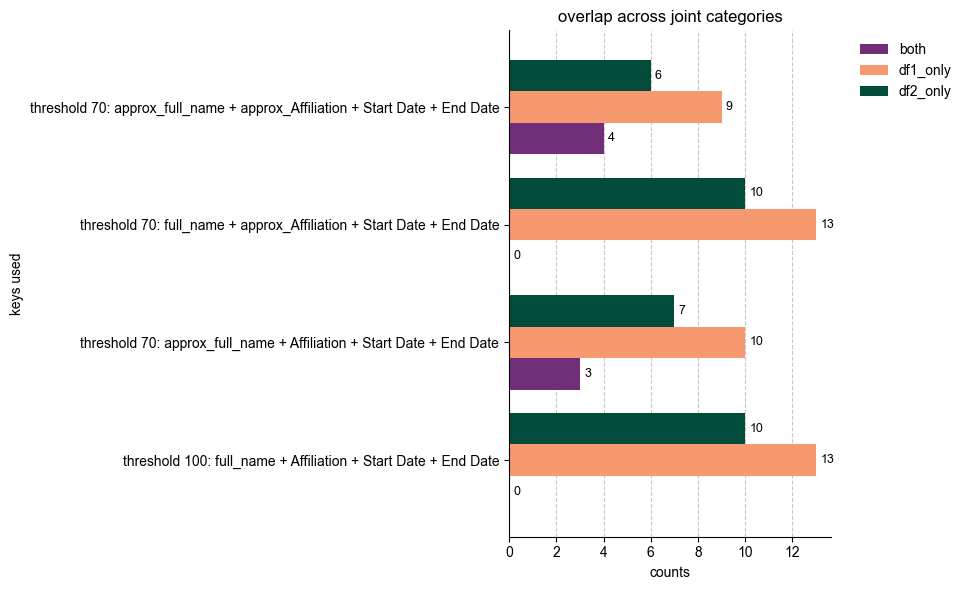

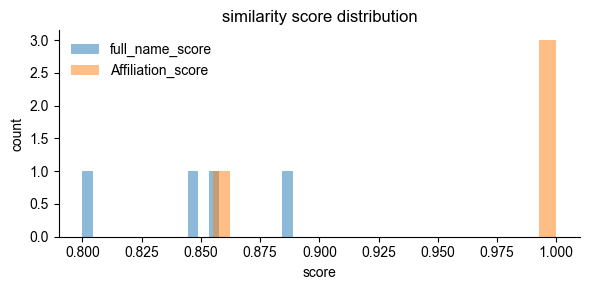

In [77]:
plt.rcParams['font.family'] = 'Arial'  # set font globally
fig, ax = plt.subplots(figsize=(10, 6))

results_df.set_index("keys_used")[["both", "df1_only", "df2_only"]].plot(
        kind='barh',
        stacked=False,
        ax=ax,
        width=0.8, color=['#712f79', '#f7996e', '#034c3c']  
    )

results_df.to_csv('results_from_threshold_matches.csv')
# Grid lines (only x-axis for readability)
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

# Labels
ax.set_xlabel("counts")
ax.set_ylabel("keys used")
ax.set_title("overlap across joint categories")

# Legend outside
ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    frameon=False
    )
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

for bars in ax.containers:
    ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

if threshold != 100 and results[-1]['scores']:
    fig_1, ax = plt.subplots(figsize=(6, 3))
    for score_name, vals in results[-1]['scores'].items():
        ax.hist(vals, bins=20, alpha=0.5, label=score_name)
        ax.set_title("similarity score distribution")
        ax.set_xlabel('score')
        ax.set_ylabel('count')
        ax.legend(frameon=False)
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
        plt.tight_layout()
plt.show()

Our graphs tell us that if we accept matches with similarity above 70%, a total of 8 out of 19 IDs have matches across both synethic datasets — with no exact matches, 3 requiring approximate name matching, and 5 requiring affiliation approximation. The histogram reveals that matched pairs never fall below 80% similarity, suggesting the pipeline is conservative rather than permissive, which is preferable for high-stakes accountability. Crucially, the near-total absence of exact matches is not merely a technical inconvenience. It reflects how inconsistent record-keeping practices in law enforcement data infrastructure can systematically obscure accountability, making tools like this pipeline a necessary bridge between raw data and actionable insight.

To understand how well the record linkage algorithm performs, we can create a confusion matrix to get summary of the true positives, false positives, etc, using the code below, along with the files we've created. Note that for real datasets, we can only create a ground truth using human review for a small subset of the records. 

In [79]:
matches_deduped = match_list.drop_duplicates(subset='EMPL_ID', keep='first')
predicted_map = dict(zip(all_so_far_deduped['EMPL_ID'], all_so_far_deduped['ID']))

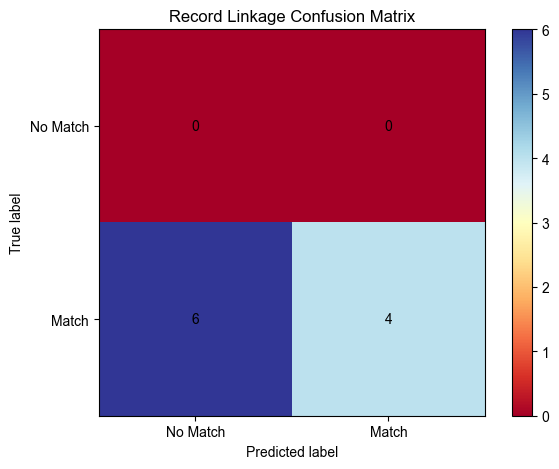

              precision    recall  f1-score   support

    No Match       0.00      0.00      0.00         0
       Match       1.00      0.40      0.57        10

    accuracy                           0.40        10
   macro avg       0.50      0.20      0.29        10
weighted avg       1.00      0.40      0.57        10



In [80]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

# Build ground truth lookup: EMPL_ID -> true ID
ground_truth_map = dict(zip(df_2['EMPL_ID'], df_2['ground_truth_match']))
# For every record in df_2, determine true label and predicted label
y_true = []
y_pred = []

for empl_id, true_id in ground_truth_map.items():
    predicted_id = predicted_map.get(empl_id, None)
    
    # True label: was there a real match?
    true_match = true_id is not None and not pd.isna(true_id)
    # Predicted label: did the pipeline find a match?
    pred_match = predicted_id is not None
    # Was the predicted match actually correct?
    correct = pred_match and (int(predicted_id) == int(true_id))
    
    y_true.append(1 if true_match else 0)
    y_pred.append(1 if correct else 0)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['No Match', 'Match'])
disp.plot(cmap='RdYlBu')
for text in disp.text_.ravel():
    text.set_color('black')
plt.title('Record Linkage Confusion Matrix')
plt.tight_layout()
plt.show()

# F1, precision, recall
print(classification_report(y_true, y_pred, target_names=['No Match', 'Match'], zero_division=0))

The confusion matrix reveals 6 false negatives — true matches the pipeline missed. 
After human review, we are able that while name variation or affiliation variation have matches within a threshold, there is a compounding error. When multiple fields are fuzzy matched simultaneously, a correct name match can be invalidated by an incorrect agency approximation — particularly when agency names share vocabulary across departments (e.g., "Dept. of Correction" being approximated to "Department of Environmental Protection" rather than "Department of Correction"). Future work would constrain agency matching to candidates that have already passed name matching.

These failure reflect how inconsistent and idiosyncratic data entry practices create systematic blind spots in automated record linkage, reinforcing the need for human review of unmatched records.